# **02. Download necessary data**

This notebook is for downloading multiple files for generating time-series labels of sea ice classification. The purpose of this notebook is to generate combined file of AI4Arctic-similar datasets but using multi-time-series data. Once you download four different types of data (i.e., ice chart (vector), Sentinel-1 SAR (raster), AMSR2 brightness temperature (raster), and ERA5 reanalysis (raster)), you will be able to combine them into a single netCDF file (.nc format).

## Arctic Ice Chart
- You can use the ice chart shapefiles (.shp) downloaded from PolarView (www.polarview.aq) and Arctic Ice Logistics Portal (www.icelogistics.info/arctic). Please use the ``DATA01_Download_chart.ipynb`` for detailed instructions of downloading these shapefiles.

## Sentinel-1 Synthetic aperture radar (SAR) images
- Sentinel-1 images are downloaded from Google Earth Engine (https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S1_GRD).
- Original resolution of Sentinel-1 image is 40 m, but we resample them into 120 m for downloading. This parameter can be adjusted in the [**Parameter setting**](#parameter_setting) cell, but please note that there is a maximum requeset size in Google Earth Engine (32 MB) you can download. If the requested array exceeds this request size, an error message may appear.
    - Bands: HH and HV

## AMSR2 Passive microwave (PMW) data
- A corresponding AMSR2 is produced, containing AMSR2 brightness temperatures resampled to the Sentinel-1 geometry. The level-1b AMSR2 product is retrieved from JAXA’s G-Portal (https://gportal.readthedocs.io/en/stable/).
    - btemp_FFP - brightness temperatures (Tb) from the instrument for frequencies FF = [6.9, 7.3, 10.7, 18.7, 23.8, 36.5, 89.0] and polarisations P = [v, h]

## ERA5 Atmospheric reanalysis data
- Following the data architecture of the AI4Arctic dataset, we use the following weather paraeters from ERA5.
    - u10m_rotated - ERA5 eastward component of the 10m wind rotated to the North polar Equal-Area Scalable Earth Grid (EASE-Grid; EPSG 3408).
    - v10m_rotated - ERA5 northward component of the 10m wind rotated to the North polar Equal-Area Scalable Earth Grid (EASE-Grid; EPSG 3408).
    - t2m - ERA5 2m air temperature.
    - skt - ERA5 skin temperature.
    - tcwv - ERA5 total column water vapor.
    - tclw - ERA5 total column cloud liquid water.

## Import functions

In [9]:
import ee
import geemap
import matplotlib.pyplot as plt

try:        
    # Initialize with your own project - Please specify your own project name.
    ee.Initialize(project = "utsa-spring2024")
except:
# Authenticate
    ee.Authenticate()
    # Initialize with your own project - Please specify your own project name.
    ee.Initialize(project = "utsa-spring2024")

import os
from datetime import datetime
import geopandas as gpd
import numpy as np

import gportal
import json
import os, glob
import requests
from datetime import datetime, timedelta

In [197]:
import requests
import geopandas as gpd
from shapely.geometry import Polygon
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio import features
import cdsapi
import xarray as xr

def add_HH(img):
    bands = img.bandNames() # First band ('HH' or 'VV')
    band = ['HH']
    norm = img.select(band).divide(img.select('angle')).rename('HH_norm')
    img2 = img.addBands(norm, overwrite=True) #.select('HH_norm')
    return img2

def add_HV(img):
    bands = img.bandNames() # First band ('HH' or 'VV')
    band = ['HV']
    norm = img.select(band).divide(img.select('angle')).rename('HV_norm')
    img2 = img.addBands(norm, overwrite=True) #.select('HH_norm')
    return img2

def add_coverage(img):    
    tol = 1000
    overlap = img.geometry().intersection(extent, tol)
    ratio = overlap.area(tol).divide(extent.area(tol)) #overlap.area(tol).divide(img.geometry().area(tol))
    return img.set({'coverage_ratio': ratio})
    
def add_area(img):    
    tol = 1000    
    return img.set({'coverage_area': img.geometry().area(tol)})
    
def add_chart_id(gdf):
    
    fields = ['CT', 'CA', 'CB', 'CC', 'CN', 'SA', 'SB', 'SC', 'CD', 'FA', 'FB', 'FC'] #gdf.keys()[3:-6]
    codes = []
    poly_id = []
    N = 0

    for i in range(0, len(gdf)):
        cd = ""
        for f in fields:
            try:
                cd += gdf.loc[i, f] + ";"
            except:
                cd += "-9;"
        if cd not in codes:
            codes.append(cd)
            poly_id.append(N)
            N += 1
            gdf.loc[i, "poly_id"] = N
            gdf.loc[i, "code"] = cd
        else:
            idx = np.where(np.array(codes) == cd)[0][0]
            gdf.loc[i, "poly_id"] = poly_id[idx]
            gdf.loc[i, "code"] = cd
        
    return gdf


def download_img(img, proj, pixel_size, extent, out_tif):
    url = img.getDownloadURL({
        'scale': pixel_size,
        'crs': proj,
        'region': extent,
        'format': 'GEO_TIFF'
    })
    
    # Download file
    response = requests.get(url)
    with open(out_tif, "wb") as f:
        f.write(response.content)
    
    print(f"Saved to {out_tif}")


def rectangle_to_gdf(coords, crs):
    """
    coords: list of 5 (x, y) or (lon, lat) tuples
    crs: CRS string, e.g., 'EPSG:4326' or 'EPSG:3408'
    """
    poly = Polygon(coords)
    return gpd.GeoDataFrame({"id": [1]}, geometry=[poly], crs=crs)

def save_chart_tif(ref_tif, chart_tif, chart2):
    # rst_fn = "output.tif"
    rst = rasterio.open(ref_tif)
    ref_img = rst.read(1)
    meta = rst.meta.copy()
    meta.update(compress='lzw')
    
    with rasterio.open(chart_tif, 'w+', **meta) as out:
        out_arr = out.read(1)
    
        # this is where we create a generator of geom, value pairs to use in rasterizing
        shapes = ((geom,value) for geom, value in zip(chart2.geometry, chart2.poly_id))
    
        burned = features.rasterize(shapes=shapes, fill=0, out=out_arr, transform=out.transform)
        out.write_band(1, burned)
        print(f"Saved to {chart_tif}")

def get_extent(center, distance, proj):
    # center = [lon, lat]
    geometry = ee.Geometry.Point(center[0], center[1])    
    # if proj == "EPSG:3857":
    #     extent = geometry.buffer(distance = distance).bounds()
    #     dp = appropriate_resolution(center, pixel_size)
    # else:
    extent = geometry.buffer(distance = distance, proj = proj).bounds(proj = proj)
    
    return extent


def get_S1_array(center, t1, t2, pixel_size = 60, distance = 100000, proj = "EPSG:3409"):
    # proj - EPSG:3409 (EASE South); EPSG:3976 (NSIDC south polar stereo); EPSG:3857 (Web Mercator)

    geometry = ee.Geometry.Point(center[0], center[1])
    
    if proj == "EPSG:3857":
        extent = geometry.buffer(distance = distance).bounds()
        dp = appropriate_resolution(center, pixel_size)
    else:
        extent = geometry.buffer(distance = distance, proj = proj).bounds(proj = proj)
        dp = pixel_size

def empty(*args, **kwargs): return ""

def retrieve_hourly_ERA5_bbox(years, months, days, hours, bbox, object):
    c = cdsapi.Client(quiet=True, wait_until_complete=False, delete=True, progress=False, warning_callback = empty, sleep_max=10)
    # dataset to read
    dataset = 'reanalysis-era5-single-levels'
    # flag to download data
    # download_flag = False
    variables = [
        '10m_u_component_of_wind', '10m_v_component_of_wind', '2m_temperature', 'skin_temperature', "total_column_cloud_liquid_water", "total_column_water_vapour"
        # 'sea_ice_cover', '2m_temperature', 'sea_ice_cover', 'surface_pressure', 'skin_temperature', 'instantaneous_10m_wind_gust', 
    ]

    # u10m_rotated, v10m_rotated, t2m, skt, tcwv, tclw -> In the AI4Arctic Dataset

    params = {
        'format': 'netcdf',
        'product_type': 'reanalysis',
        'variable': variables,
        'year': years,
        'month': months,
        'day': days,
        'time': hours,
        'grid': [1.0, 0.5],
        'area': [bbox[1], bbox[0], bbox[3], bbox[2]]
        }

    # retrieves the path to the file
    # target = 'download.nc'
    if object == None:
        print("Please provide the correct file name!")
        # fl = c.retrieve(dataset, params).download()
        # ds = xr.open_dataset(fl)
        # return ds, fl
    else:
        c.retrieve(dataset, params, object)

def rotate_vector(u, v, lon, ref_lon = 0, hemi = "NH"):
    # Latitude & longitude grid to polar grid
    # ref_lon: longitude of top bottom
    if hemi == "NH":
        angle = (lon-ref_lon)*np.pi/180 # rotation angle (radian)
    else:
        angle = -(lon-ref_lon)*np.pi/180
    u2 = u*np.cos(angle) - v*np.sin(angle)
    v2 = u*np.sin(angle) + v*np.cos(angle)
    return u2, v2

def hour_rounder(t):
    return (t.replace(second=0, microsecond=0, minute=0, hour=t.hour)
               +timedelta(hours=t.minute//30))

def get_intersection(gdf1, gdf2, proj):
    # Calculate intersection area between two polygons
    intersection = gpd.overlay(gdf1.to_crs(proj), gdf2.to_crs(proj), how="intersection")
    
    intersection["overlap_area"] = intersection.geometry.area
    total_overlap_area = intersection["overlap_area"].sum()
    area1 = gdf1.geometry.area.sum()
    percent_overlap = (total_overlap_area / area1) * 100
    return percent_overlap.item()

<a id="parameter_setting"></a>
## Parameter Setting

In [131]:
##### PARAMETERS ####################################################
# Directory to save the output files
folder = 'C:\\Users\\yoko2261\\OneDrive - UCB-O365\\CAIG\\TS\\'
# Directory of ice chart shapefiles
chart_folder = "C:\\Users\\yoko2261\\OneDrive - UCB-O365\\CAIG\\Ice_chart\\"

proj = 'EPSG:3408'
pixel_size = 120

# Earliest date: 2024/08/10
startdate = '2025-01-01' 
enddate = '2026-01-01'

lats = [72, 75, 69]
lons = [-148, -170, -171]

order = 2
lat0 = 70 #lats[order]
lon0 = -138 #lons[order]
center = [lon0, lat0]
distance = 120000 # Radius of extent from the center (lon0, lat0)
extent = get_extent(center, distance, proj)
extent_gdf = geemap.ee_to_gdf(ee.FeatureCollection(extent.transform(proj='EPSG:4326', maxError=10))).to_crs(proj)

In [226]:
# Find what ice chart corresponds to the target area
extent
chart_ids = []
dfc = pd.DataFrame()
i = 0

for agency in os.listdir(chart_folder): #, "CIS", "NOAA", "METNO", "DMI"]: # What ice centers you are interested in?
    folders = [f for f in os.listdir(chart_folder + agency) if f[-4:] != ".zip"]   
    
    for f in folders:
        chart_id = f.split("_")[1]
        date = datetime.strptime(f.split("_")[2], "%Y%m%d")
        
        if (chart_id not in chart_ids) & (date >= datetime.strptime(startdate, "%Y-%m-%d")) & (date <= datetime.strptime(enddate, "%Y-%m-%d")):
            chart_ids.append(chart_id)
            file = glob.glob(os.path.join(chart_folder + agency, f) + "\\*.shp")[0]
            polygon = gpd.read_file(file)
            r = get_intersection(extent_gdf, polygon, proj)
            if r > 50:
                dfc.loc[i, "agency"] = agency
                dfc.loc[i, "chart_id"] = chart_id
                dfc.loc[i, "folder"] = chart_folder + agency
                dfc.loc[i, "first_date"] = date.strftime("%Y%m%d")
                i += 1

# Make folder to download ice chart tiff files
subfolder = folder + f"Chart\\{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}"
if not os.path.exists(subfolder):
    os.makedirs(subfolder)
dfc.to_csv(f"{subfolder}\\Chart_list_{str(int(lat0)).zfill(2)}_{str(int(lon0))}.csv")

## Download datasets (S1, AMSR2, EREA5)

In [219]:
#####################################################################

# Create polygon from EPSG:3408 coordinates
coords = extent.getInfo()['coordinates']
coords2 = [(xys[0], xys[1]) for xys in coords[0]]
# poly = Polygon(coords_3408)

# Build GeoDataFrame
extent_gdf = rectangle_to_gdf(coords2, proj)

source = "COPERNICUS/S1_GRD"
S1 = ee.ImageCollection(source)\
  .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'HH'))\
  .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'HV'))\
  .filterDate(startdate, enddate)\
  .filterBounds(extent);

# S1 = S1.map(add_HH)
S1 = S1.map(add_coverage).map(add_area)

S1 = S1.filter(ee.Filter.gt('coverage_ratio', 0.75)) #.filter(ee.Filter.gt('coverage_area', 8e10))
num = S1.size().getInfo()
print("Number of S1 images: ", num)
# print(S1.aggregate_array("coverage_ratio").getInfo())

files = S1.aggregate_array("system:id").getInfo() 
coverages = S1.aggregate_array("coverage_ratio").getInfo() 

first = True
df = pd.DataFrame({'S1_id': files, 'coverage_ratio': coverages})
df['lat'] = lat0
df['lon'] = lon0
df['proj'] = proj
df.to_csv(folder + f"S1\\S1_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.csv")

for f in files[:]:
    time0 = f.split("_")[-5]
    date0 = time0[:8]
    
    print(f, date0)
    
    ### ====== Sentinel-1 images =====
    img = ee.Image(f).setDefaultProjection(proj)

    band_coord = ee.Image.pixelCoordinates(proj)
    img = img.addBands(band_coord)
    
    img_hh = img.select('HH').clip(extent)
    img_hv = img.select('HV').clip(extent)
    img_angle = img.select('angle').clip(extent)
    img_xx = img.select('x').clip(extent)
    img_yy = img.select('y').clip(extent)

    if first:
        bands = ['HH', 'HV', 'angle', 'x', 'y']
        first = False
    else:
        bands = ['HH', 'HV', 'angle']

    # Make folder to download ice chart tiff files
    subfolder = folder + f"S1\\{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}"
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
        
    for band in bands:
        img2 = img.select(band).clip(extent)
        if band in ['x', 'y']:
            out_tif = f"{subfolder}\\S1_{band}_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.tif"
        else:
            out_tif = f"{subfolder}\\S1_{band}_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}_{time0}.tif"
            
        if os.path.exists(out_tif) == False:
            download_img(img2, proj, pixel_size, extent, out_tif)

    ### ===== Ice Chart =====
    for i in range(0, len(dfc)):
        charts = os.listdir(dfc.loc[i, "folder"])
        for chart in charts:
            if (abs(datetime.strptime(chart.split("_")[2], "%Y%m%d") - datetime.strptime(date0, "%Y%m%d")).days < 7) & (chart.split("_")[1] == dfc.loc[i, "chart_id"]):
                chartname = glob.glob(os.path.join(dfc.loc[i, "folder"], chart) + "\\*.shp")[0]
                polygon = gpd.read_file(chartname).to_crs(proj)
                polygon = add_chart_id(polygon)
                # chart2 = chart.clip(extent_gdf).reset_index(drop = True)
        
                # Make folder to download ice chart tiff files
                subfolder = folder + f"Chart\\{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}"
                if not os.path.exists(subfolder):
                    os.makedirs(subfolder)
                
                chart_tif = f"{subfolder}\\{chart}_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.tif"
                if os.path.exists(chart_tif) == False:
                    save_chart_tif(out_tif, chart_tif, polygon)        
                    polygon.to_csv(chart_tif.replace(".tif", ".csv"))
        
    ### ===== AMSR =====
    bbox=[lon0-2, lat0-1, lon0+2, lat0+1]
    start_time = datetime.strptime(f"{time0}", "%Y%m%dT%H%M%S") - timedelta(seconds = 3600*3)
    end_time = datetime.strptime(f"{time0}", "%Y%m%dT%H%M%S") + timedelta(seconds = 3600*3)
    res = gportal.search(
        dataset_ids=['11001002'], # 'L2-Sea Ice Concentration（SIC)': ['11002013', '11002006']; 'L1R-Brightness temperature（TB）': ['11001002'] L1R Brightness temp: ['11001002'],  # l1r - see gportal.datasets()
        start_time=start_time,
        end_time=end_time,
        bbox=bbox
    )

    print(f"Matched for {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S')}: {res.matched()}")

    products = res.products()
    scratch = folder + "AMSR\\"
    
    for product in res.products():
        # print(product.data_url)    
    
        out_file = os.path.join(scratch, product.id + ".nc")
        if os.path.exists(out_file) and os.path.getsize(out_file) > 0:
            print(f"file {out_file} exists, skipping download")
            # return out_file
        else:
            response = requests.get(product.data_url)
        
            os.makedirs(scratch, exist_ok=True)
            
            if response.status_code == 200:
                with open(out_file, 'wb') as file:
                    file.write(response.content)
                print(f'AMSR ({product.id}) downloaded successfully')

    ### ===== ERA5 =====
    bbox2=[lon0-8, lat0-4, lon0+8, lat0+4]
    t = hour_rounder(datetime.strptime(f"{time0}", "%Y%m%dT%H%M%S"))
    years = [f"{str(t.year).zfill(4)}"]
    months = [f"{str(t.month).zfill(2)}"]
    days = [f"{str(t.day).zfill(2)}"]
    hours = [f"{str(t.hour).zfill(2)}:00"]

    subfolder = folder + f"ERA5\\{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}"
    if not os.path.exists(subfolder):
        os.makedirs(subfolder)
    file_era5 = f"{subfolder}\\ERA5_{time0}_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.nc"
    retrieve_hourly_ERA5_bbox(years, months, days, hours, bbox2, file_era5)
    print(f"ERA5 downloaded - {file_era5}")

print("DONE!")

Number of S1 images:  57
COPERNICUS/S1_GRD/S1A_EW_GRDM_1SDH_20250105T155415_20250105T155452_057311_070D3E_9DA0 20250105
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\S1\70_-138\S1_HH_70_-138_20250105T155415.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\S1\70_-138\S1_HV_70_-138_20250105T155415.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\S1\70_-138\S1_angle_70_-138_20250105T155415.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\S1\70_-138\S1_x_70_-138.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\S1\70_-138\S1_y_70_-138.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\Chart\70_-138\CIS_2230_20250106_70_-138.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\Chart\70_-138\NIC_10013_20250103_70_-138.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\Chart\70_-138\NOAA_1900_20250101_70_-138.tif
Saved to C:\Users\yoko2261\OneDrive - UCB-O365\CAIG\TS\Chart\70_-138\NOAA_1900_20250102_70_-138.tif
Saved to C:\


KeyboardInterrupt



## Analyze data

In [312]:
def read_tif(file):
    with rasterio.open(file) as rst:
        array = rst.read(1)
        array[array == 0] = np.nan
    return array

##### PARAMETERS ####################################################
folder = 'C:\\Users\\yoko2261\\OneDrive - UCB-O365\\CAIG\\TS\\'
proj = 'EPSG:3408'
pixel_size = 120

# Earliest date: 2024/08/10
startdate = '2024-09-01' 
enddate = '2025-10-01'

year = 2025
month = "11"

for month in ["02"]: #["01", "02", "03", "04", "05"]: #["10", "11", "12"]:
    center = [lon0, lat0]
    distance = 120000
    extent = get_extent(center, distance, proj)
    #####################################################################
    
    # Create polygon from EPSG:3408 coordinates
    coords = extent.getInfo()['coordinates']
    coords2 = [(xys[0], xys[1]) for xys in coords[0]]
    # poly = Polygon(coords_3408)
    
    # Build GeoDataFrame
    extent_gdf = rectangle_to_gdf(coords2, proj)
    subfolder = f"{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}"
    S1_images = sorted(glob.glob(folder + f"S1\\{subfolder}\\S1_HH_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}_{year}{month}*.tif"))
    chart_images = sorted(glob.glob(folder + f"Chart\\{subfolder}\\*_{year}{month}*_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.tif"))
    chart_unique = unique_value([os.path.basename(c).split("_")[0] + "_" + os.path.basename(c).split("_")[1] for c in chart_images])
    
    xx = read_tif(folder + f"S1\\{subfolder}\\S1_x_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.tif")
    yy = read_tif(folder + f"S1\\{subfolder}\\S1_y_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}.tif")
    row, col = xx.shape
    
    N = len(S1_images[:])
    
    array_HH = np.zeros((N, row, col))
    array_HV = np.zeros((N, row, col))
    array_CT = np.zeros((len(chart_unique), N, row, col))
    array_SA = np.zeros((len(chart_unique), N, row, col))
    dates = []
    dates_chart = np.zeros((len(chart_unique), N))
    
    for n in range(0, N):
        S1_file = S1_images[n]
        
        time0 = S1_file[-19:-4] #f.split("_")[-5]
        date0 = time0[:8]
    
        dates.append(date0)       
    
        array_HH[n] = read_tif(S1_file)
        array_HV[n] = read_tif(S1_file.replace("S1_HH", "S1_HV"))              

        for c in range(0, len(chart_unique)):
            CT = np.zeros((row, col))
            SA = np.zeros((row, col))
            chart_list = glob.glob(folder + f"Chart\\{subfolder}\\{chart_unique[c]}_{year}{month}*.tif")

            chart_file = find_nearest_chart(S1_file, chart_list)

            array_chart = read_tif(chart_file)  
        
            chart = pd.read_csv(chart_file.replace(".tif", ".csv"), index_col = 0)
            for poly_id in np.unique(array_chart):
                CT[array_chart == poly_id] = chart.loc[chart['poly_id'] == poly_id, "CT"].mean()
                SA[array_chart == poly_id] = chart.loc[chart['poly_id'] == poly_id, "SA"].mean()
        
            array_CT[c, n] = CT
            array_SA[c, n] = SA
            dates_chart[c, n] = os.path.basename(chart_file).split("_")[2]

            print(os.path.basename(S1_file), os.path.basename(chart_file))

    print("DONE!")

S1_HH_70_-138_20250210T155413.tif CIS_2230_20250210_70_-138.tif
S1_HH_70_-138_20250210T155413.tif NIC_10013_20250207_70_-138.tif
S1_HH_70_-138_20250210T155413.tif NOAA_1900_20250210_70_-138.tif
S1_HH_70_-138_20250222T155412.tif CIS_2230_20250224_70_-138.tif
S1_HH_70_-138_20250222T155412.tif NIC_10013_20250221_70_-138.tif
S1_HH_70_-138_20250222T155412.tif NOAA_1900_20250222_70_-138.tif
DONE!


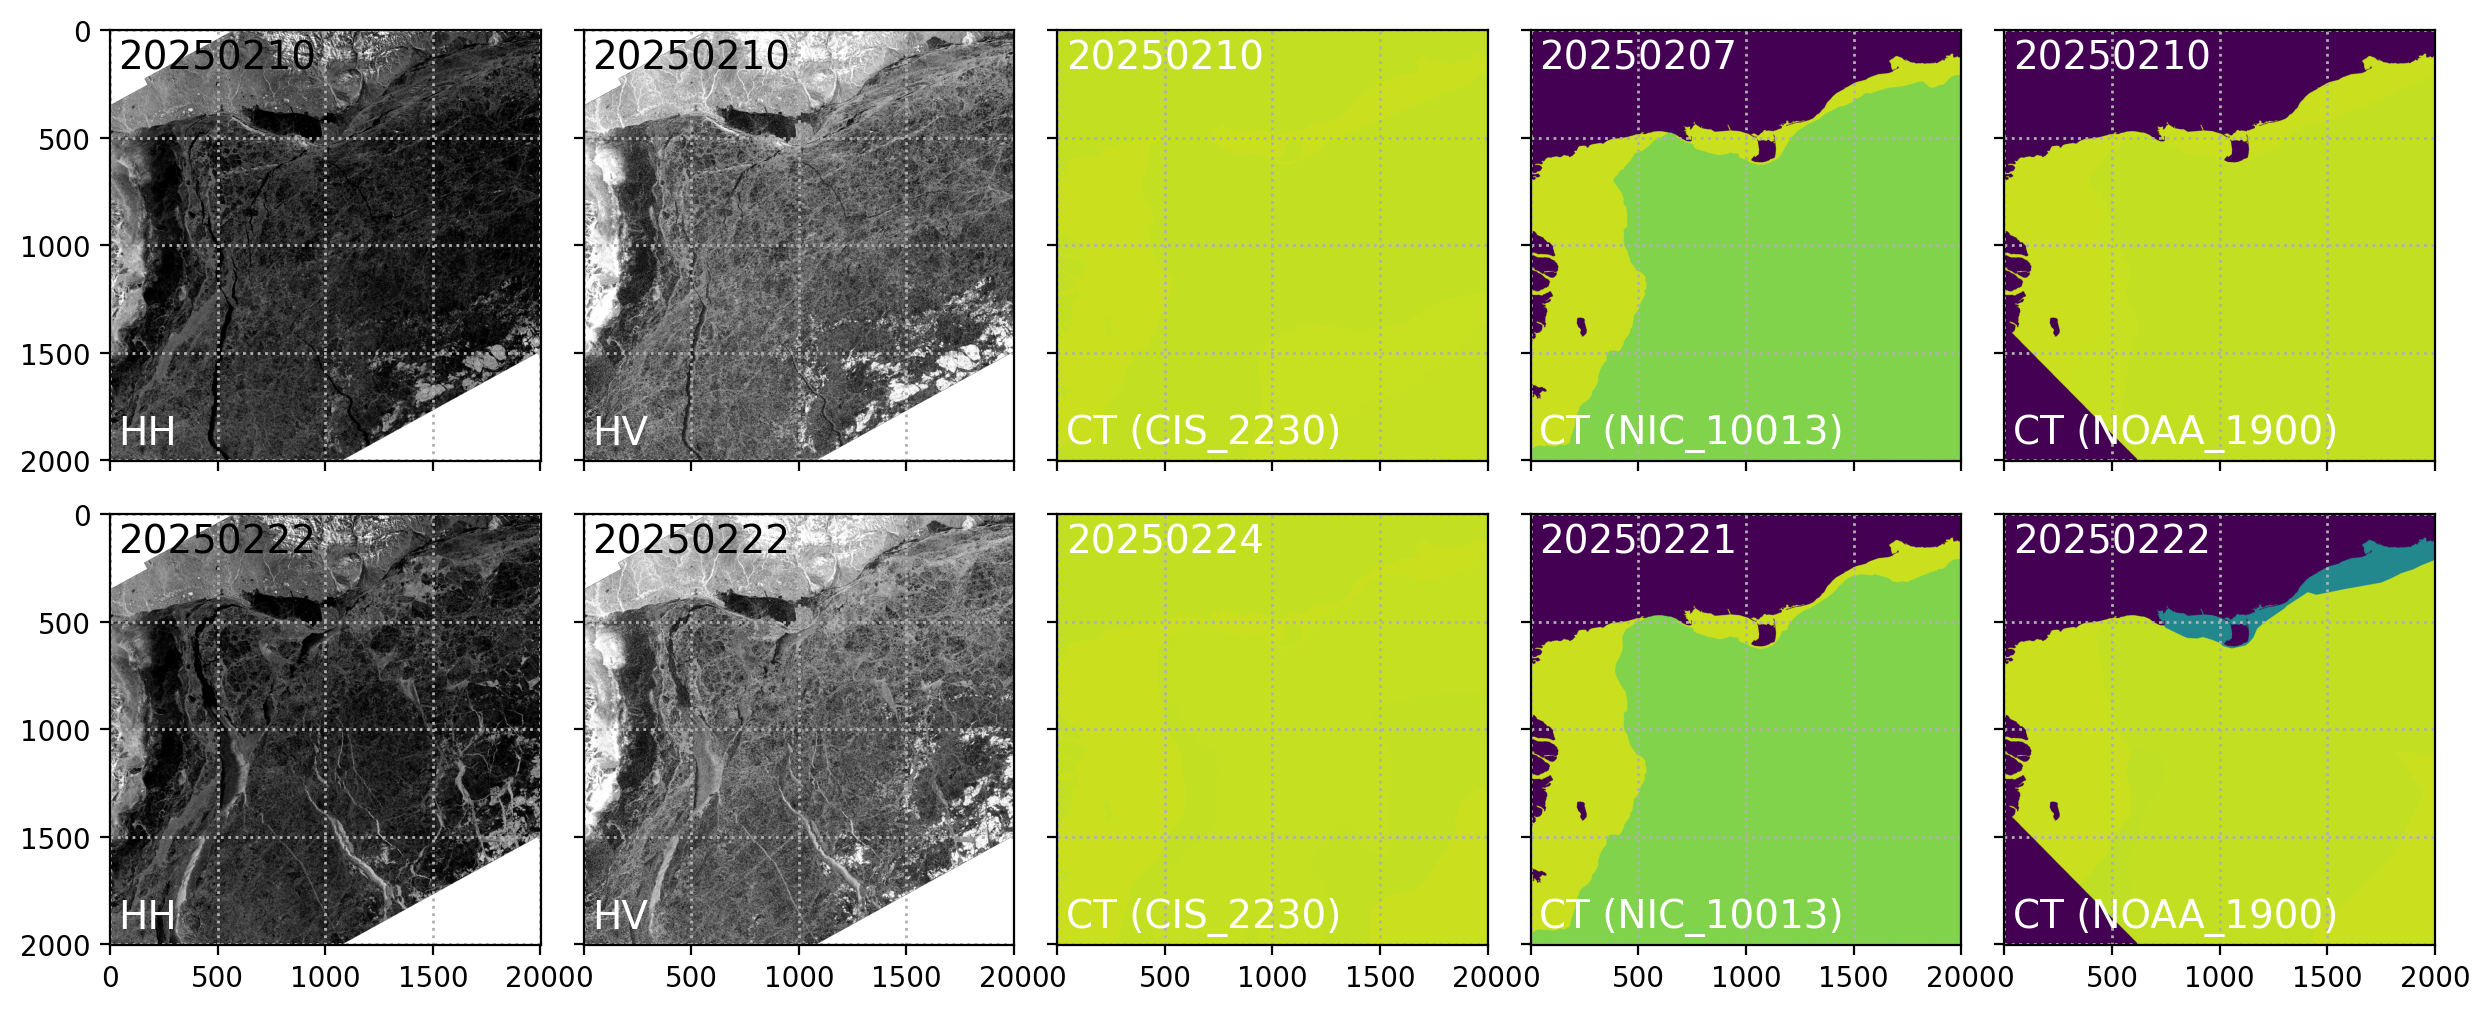

In [313]:
fig, ax = plt.subplots(N, 2+len(chart_unique), figsize = (3*(2+len(chart_unique)), 3*N), dpi = 200, sharex = True, sharey = True, num = 1, clear = True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

for n in range(0, N):
    # ax[n].pcolormesh(xx, yy, array_HH[n])
    ax[n, 0].imshow(array_HH[n], vmin = -20, vmax = -5, cmap = "gray")
    ax[n, 1].imshow(array_HV[n], vmin = -40, vmax = -20, cmap = "gray")    
    ax[n, 0].annotate("HH", xy=(0.02, 0.02), xycoords='axes fraction', size = 14, va = 'bottom', ha ='left', color = "w")
    ax[n, 1].annotate("HV", xy=(0.02, 0.02), xycoords='axes fraction', size = 14, va = 'bottom', ha ='left', color = "w")

    for k in range(0, len(chart_unique)):
        ax[n, 2+k].imshow(array_CT[k, n], vmin = 0, vmax = 100)
        ax[n, 2+k].annotate(f"CT ({chart_unique[k]})", xy=(0.02, 0.02), xycoords='axes fraction', size = 14, va = 'bottom', ha ='left', color = "w")
    
    for m in range(0, 2+len(chart_unique)):
        ax[n, m].grid(ls = ":", lw = 1.0)        
        if m < 2:
            ax[n, m].annotate(dates[n], xy=(0.02, 0.98), xycoords='axes fraction', size = 14, va = 'top', ha ='left')
        else:
            ax[n, m].annotate(int(dates_chart[m-2, n]), xy=(0.02, 0.98), xycoords='axes fraction', size = 14, va = 'top', ha ='left', color = "w")

# plt.savefig(folder + f"\\Figure\\TS_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}_{year}{month}.png", bbox_inches = "tight")
# fig.clear()
# plt.close(fig)

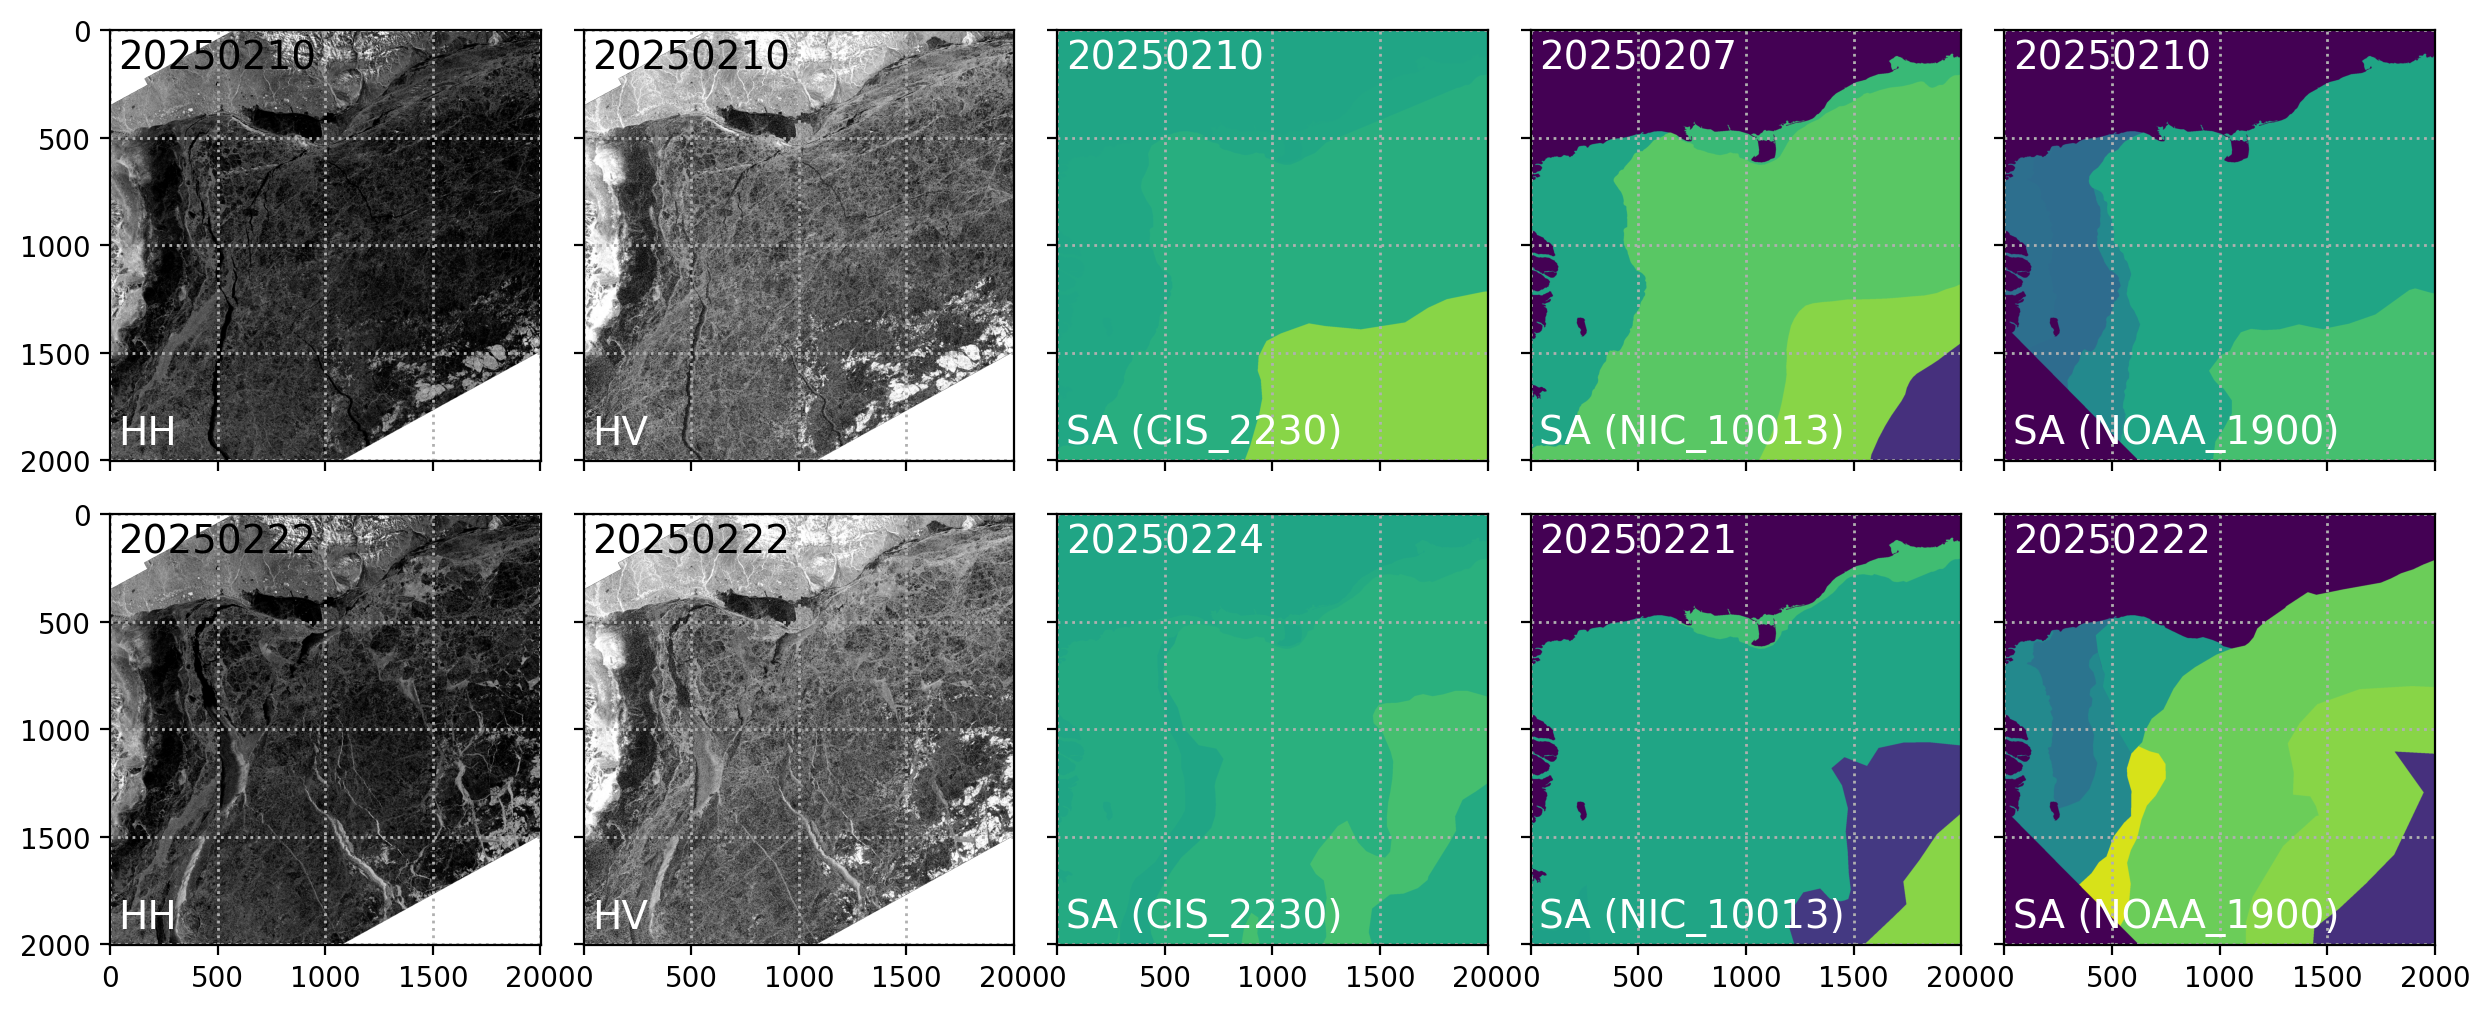

In [314]:
fig, ax = plt.subplots(N, 2+len(chart_unique), figsize = (3*(2+len(chart_unique)), 3*N), dpi = 200, sharex = True, sharey = True, num = 1, clear = True)
plt.subplots_adjust(hspace=0.1, wspace=0.1)

for n in range(0, N):
    # ax[n].pcolormesh(xx, yy, array_HH[n])
    ax[n, 0].imshow(array_HH[n], vmin = -20, vmax = -5, cmap = "gray")
    ax[n, 1].imshow(array_HV[n], vmin = -40, vmax = -20, cmap = "gray")    
    ax[n, 0].annotate("HH", xy=(0.02, 0.02), xycoords='axes fraction', size = 14, va = 'bottom', ha ='left', color = "w")
    ax[n, 1].annotate("HV", xy=(0.02, 0.02), xycoords='axes fraction', size = 14, va = 'bottom', ha ='left', color = "w")

    for k in range(0, len(chart_unique)):        
        ax[n, 2+k].imshow(array_SA[k, n], vmin = 81, vmax = 98)
        ax[n, 2+k].annotate(f"SA ({chart_unique[k]})", xy=(0.02, 0.02), xycoords='axes fraction', size = 14, va = 'bottom', ha ='left', color = "w")
    
    for m in range(0, 2+len(chart_unique)):
        ax[n, m].grid(ls = ":", lw = 1.0)        
        if m < 2:
            ax[n, m].annotate(dates[n], xy=(0.02, 0.98), xycoords='axes fraction', size = 14, va = 'top', ha ='left')
        else:
            ax[n, m].annotate(int(dates_chart[m-2, n]), xy=(0.02, 0.98), xycoords='axes fraction', size = 14, va = 'top', ha ='left', color = "w")

# plt.savefig(folder + f"\\Figure\\TS_{str(int(lat0)).zfill(2)}_{str(int(lon0)).zfill(3)}_{year}{month}.png", bbox_inches = "tight")
# fig.clear()
# plt.close(fig)